# TECHIN 513 Final Project — Music-to-Imagine
**Team 18: Taya Li & Yilu Huang**

Pipeline: Audio Input → Preprocessing → Feature Extraction → Energy Labeling → ML Classification → Visual Mapping

## Step 1: Load Audio (Test Single File)

In [15]:
import librosa
import numpy as np
import os

BASE_DIR = '/Users/tong/Downloads/513final'
DATASET_PATH = os.path.join(BASE_DIR, 'Data', 'genres_original')
CSV_PATH = os.path.join(BASE_DIR, 'Data', 'features.csv')

# Test: load one song
genre = "rock"
filename = os.listdir(f"{DATASET_PATH}/{genre}")[0]
filepath = f"{DATASET_PATH}/{genre}/{filename}"

y, sr = librosa.load(filepath, sr=22050, mono=True)
print(f"Loaded successfully: {filename}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.1f} seconds")

Loaded successfully: rock.00011.wav
Sample rate: 22050
Duration: 30.0 seconds


## Step 2 & 3: Feature Extraction (19 features)

In [16]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050, mono=True)
    
    # 1. RMS Energy（响度/强度）
    rms = np.mean(librosa.feature.rms(y=y))
    
    # 2. Zero Crossing Rate（噪声感）
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    
    # 3. Spectral Centroid（音色亮度）
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    
    # 4. Spectral Flux（动态变化）
    flux = np.mean(librosa.onset.onset_strength(y=y, sr=sr))
    
    # 5. Tempo（节拍速度）
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(np.atleast_1d(tempo)[0])
    
    # 6-18. 13 MFCCs（音色/timbre）
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = list(np.mean(mfcc, axis=1))
    
    # 总共 18 个特征
    return [rms, zcr, centroid, flux, tempo] + mfcc_means

# 测试单首歌
features = extract_features(filepath)
print(f"RMS Energy:         {features[0]:.6f}")
print(f"Zero Crossing Rate: {features[1]:.6f}")
print(f"Spectral Centroid:  {features[2]:.2f}")
print(f"Spectral Flux:      {features[3]:.6f}")
print(f"Tempo:              {features[4]:.2f} BPM")
print(f"MFCCs (1-13):       {[round(m,2) for m in features[5:]]}")
print(f"\n总特征数: {len(features)}")

RMS Energy:         0.123355
Zero Crossing Rate: 0.054330
Spectral Centroid:  1537.47
Spectral Flux:      1.388435
Tempo:              117.45 BPM
MFCCs (1-13):       [np.float32(-169.68), np.float32(119.11), np.float32(7.16), np.float32(53.43), np.float32(4.13), np.float32(23.13), np.float32(-5.72), np.float32(24.99), np.float32(-9.33), np.float32(13.47), np.float32(-14.28), np.float32(5.96), np.float32(-13.6)]

总特征数: 18


## Step 4: Batch Processing (All 999 Tracks)

In [17]:
import pandas as pd
columns = ['genre', 'filename', 'rms', 'zcr', 'centroid', 'flux', 'tempo'] + \
          [f'mfcc_{i}' for i in range(1, 14)]

rows = []
genres = os.listdir(DATASET_PATH)
genres = [g for g in genres if os.path.isdir(f"{DATASET_PATH}/{g}")]

for genre in sorted(genres):
    genre_path = f"{DATASET_PATH}/{genre}"
    files = sorted(os.listdir(genre_path))
    for fname in files:
        if not fname.endswith('.wav'):
            continue
        fpath = f"{genre_path}/{fname}"
        try:
            feats = extract_features(fpath)
            rows.append([genre, fname] + feats)
        except Exception as e:
            print(f"跳过 {fname}: {e}")

df = pd.DataFrame(rows, columns=columns)
df.to_csv('/Users/tong/Downloads/513final/Data/features.csv', index=False)
print(f"处理完成: {len(df)} 首歌")
print(df.head())

/var/folders/xr/8ljc5y1123lgp1ftml3dp0xm0000gn/T/ipykernel_18308/3752095166.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050, mono=True)
/opt/anaconda3/envs/techin509/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


跳过 jazz.00054.wav: 
处理完成: 999 首歌
   genre         filename       rms       zcr     centroid      flux  \
0  blues  blues.00000.wav  0.130184  0.083045  1784.122641  1.391777   
1  blues  blues.00001.wav  0.095908  0.056040  1530.261767  1.445264   
2  blues  blues.00002.wav  0.175473  0.076291  1552.832481  1.638602   
3  blues  blues.00003.wav  0.141040  0.033309  1070.153418  1.248168   
4  blues  blues.00004.wav  0.091501  0.101461  1835.128513  1.645293   

        tempo      mfcc_1      mfcc_2     mfcc_3     mfcc_4     mfcc_5  \
0  123.046875 -113.598824  121.570671 -19.162262  42.363941  -6.362266   
1   67.999589 -207.523834  123.985138   8.947019  35.867149   2.909595   
2  161.499023  -90.757164  140.440872 -29.084547  31.686693 -13.976547   
3   63.024009 -199.575134  150.086105   5.663404  26.855282   1.770071   
4  135.999178 -160.354172  126.209496 -35.581394  22.139256 -32.473549   

      mfcc_6     mfcc_7     mfcc_8     mfcc_9    mfcc_10    mfcc_11   mfcc_12  \
0  18.62

## Step 5: Energy Label Design (RMS + Tempo Percentile)

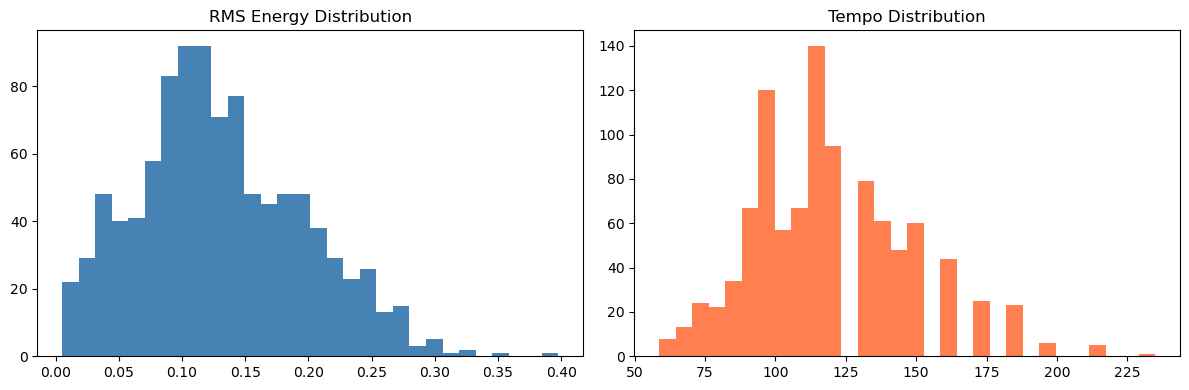

Detected existing energy_label in features.csv, will reuse it.

标签分布:
energy_label
Medium    380
Low       329
High      290
Name: count, dtype: int64


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 直接读取已有的 features.csv
df = pd.read_csv('/Users/tong/Downloads/513final/Data/features.csv')

# 分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['rms'], bins=30, color='steelblue')
axes[0].set_title('RMS Energy Distribution')
axes[1].hist(df['tempo'], bins=30, color='coral')
axes[1].set_title('Tempo Distribution')
plt.tight_layout()
os.makedirs('/Users/tong/Downloads/513final/Data/figures', exist_ok=True)
plt.savefig('/Users/tong/Downloads/513final/Data/figures/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 如果已经有 energy_label，就直接使用并打印分布，跳过重新打标签
if 'energy_label' in df.columns:
    print('Detected existing energy_label in features.csv, will reuse it.')
    print('\n标签分布:')
    print(df['energy_label'].value_counts())
else:
    # 仅在没有 energy_label 时才重新打标签
    # 百分位阈值
    rms_low, rms_high = df['rms'].quantile(0.33), df['rms'].quantile(0.67)
    tempo_low, tempo_high = df['tempo'].quantile(0.33), df['tempo'].quantile(0.67)
    print(f"RMS thresholds:   low={rms_low:.4f}, high={rms_high:.4f}")
    print(f"Tempo thresholds: low={tempo_low:.2f}, high={tempo_high:.2f} BPM")

    def label_energy(row):
        rms_score = 0 if row['rms'] < rms_low else (1 if row['rms'] < rms_high else 2)
        tempo_score = 0 if row['tempo'] < tempo_low else (1 if row['tempo'] < tempo_high else 2)
        avg = (rms_score + tempo_score) / 2
        if avg < 0.75:
            return 'Low'
        elif avg < 1.5:
            return 'Medium'
        else:
            return 'High'

    df['energy_label'] = df.apply(label_energy, axis=1)
    print('\n标签分布:')
    print(df['energy_label'].value_counts())

## Step 6: ML Classification (LR / SVM / Random Forest)


=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.82      0.79      0.81        58
         Low       0.89      0.89      0.89        66
      Medium       0.76      0.78      0.77        76

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



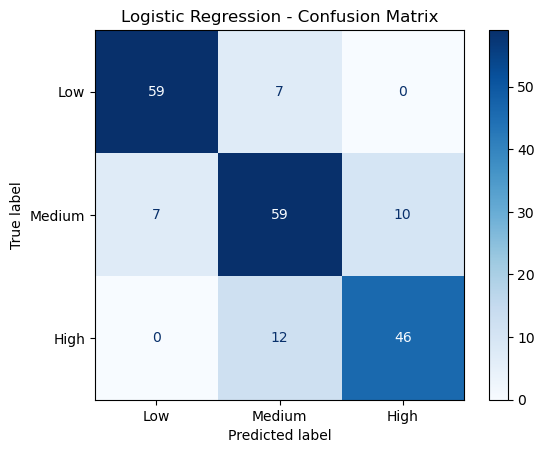


=== SVM ===
              precision    recall  f1-score   support

        High       0.92      0.81      0.86        58
         Low       0.89      0.86      0.88        66
      Medium       0.76      0.86      0.81        76

    accuracy                           0.84       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.85      0.84      0.85       200



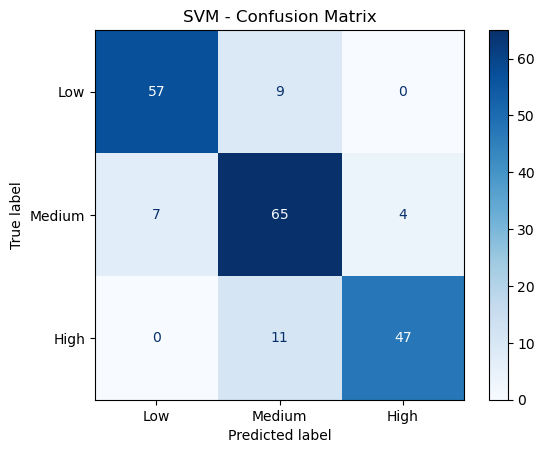


=== Random Forest ===
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        58
         Low       0.99      1.00      0.99        66
      Medium       0.99      0.99      0.99        76

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



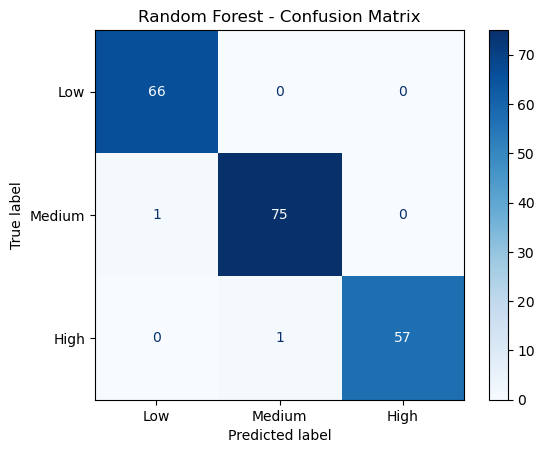

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

feature_cols = ['rms', 'zcr', 'centroid', 'flux', 'tempo'] + [f'mfcc_{i}' for i in range(1, 14)]

X = df[feature_cols].values
y = df['energy_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

os.makedirs('/Users/tong/Downloads/513final/Data/figures', exist_ok=True)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Low', 'Medium', 'High'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    safe_name = name.lower().replace(' ', '_')
    plt.savefig(f'/Users/tong/Downloads/513final/Data/figures/cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Step 7: Ablation Study
**Goal**: Show how model accuracy changes as we add more features step by step.

This answers: *"Do all 18 features contribute? Which ones matter most?"*

Uses the same train/test split as Step 6 above.

In [7]:
# ── Ablation Study: same split as Step 6 ──
from sklearn.metrics import accuracy_score

mfcc_cols = [f'mfcc_{i}' for i in range(1, 14)]

feature_groups = [
    ('RMS only',                     ['rms']),
    ('+ ZCR',                        ['rms', 'zcr']),
    ('+ Spectral Centroid',          ['rms', 'zcr', 'centroid']),
    ('+ Spectral Flux',              ['rms', 'zcr', 'centroid', 'flux']),
    ('+ Tempo',                      ['rms', 'zcr', 'centroid', 'flux', 'tempo']),
    ('+ All MFCC (full 18)',         ['rms', 'zcr', 'centroid', 'flux', 'tempo'] + mfcc_cols),
]

# Use the SAME X_train/X_test split from Step 6 (array-based, not index-based)
results = []

for name, cols in feature_groups:
    col_idx = [feature_cols.index(c) for c in cols]
    X_tr = X_train_scaled[:, col_idx]
    X_te = X_test_scaled[:, col_idx]

    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_te))

    results.append({'Features': name, 'Accuracy': round(acc * 100, 1), 'N': len(cols)})
    print(f'{name:45s} → {acc*100:.1f}%')

results_df = pd.DataFrame(results)
print('\nDone ✅')


RMS only                                      → 55.5%
+ ZCR                                         → 58.0%
+ Spectral Centroid                           → 58.0%
+ Spectral Flux                               → 60.5%
+ Tempo                                       → 89.5%
+ All MFCC (full 18)                          → 84.5%

Done ✅


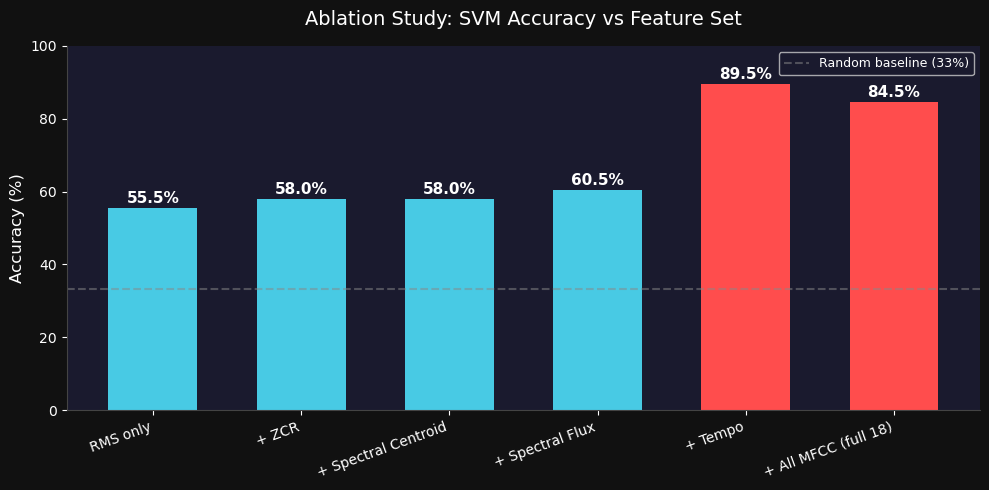

Saved as ablation_study.png ✅


In [8]:
# ── Plot ablation results ──
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#1a1a2e')

colors = ['#48cae4' if acc < 70 else '#70e000' if acc < 82 else '#ff4d4d'
          for acc in results_df['Accuracy']]

bars = ax.bar(range(len(results_df)), results_df['Accuracy'],
              color=colors, edgecolor='none', width=0.6)

for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc}%', ha='center', va='bottom',
            color='white', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Features'], rotation=20, ha='right',
                   color='white', fontsize=10)
ax.set_ylabel('Accuracy (%)', color='white', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Ablation Study: SVM Accuracy vs Feature Set', color='white', fontsize=14, pad=15)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=33.3, color='#888888', linestyle='--', alpha=0.5, label='Random baseline (33%)')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/tong/Downloads/513final/Data/figures/ablation_study.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()
print('Saved as ablation_study.png ✅')


In [9]:
# ── Print summary table for report ──
print('=== Ablation Study Results ===')
print(results_df[['Features', 'N', 'Accuracy']].to_string(index=False))
print()
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f'Best configuration: {best["Features"]} ({best["Accuracy"]}%)')

print('\n=== Accuracy gain per feature group added ===')
for i in range(1, len(results_df)):
    delta = results_df.iloc[i]['Accuracy'] - results_df.iloc[i-1]['Accuracy']
    sign = '+' if delta >= 0 else ''
    print(f'  Adding {results_df.iloc[i]["Features"].split("+")[-1].strip():30s}: {sign}{delta:.1f}%')


=== Ablation Study Results ===
            Features  N  Accuracy
            RMS only  1      55.5
               + ZCR  2      58.0
 + Spectral Centroid  3      58.0
     + Spectral Flux  4      60.5
             + Tempo  5      89.5
+ All MFCC (full 18) 18      84.5

Best configuration: + Tempo (89.5%)

=== Accuracy gain per feature group added ===
  Adding ZCR                           : +2.5%
  Adding Spectral Centroid             : +0.0%
  Adding Spectral Flux                 : +2.5%
  Adding Tempo                         : +29.0%
  Adding All MFCC (full 18)            : -5.0%
